# Koopman oracle for the four-phase cycle

Before introducing a neural encoder, we validate the full calculation using the ground-truth features. Phase evolves as `r → r+1 mod 4`, and we use centered indicators `ψ_c(r)=e_r−¼1`. Their span has dimension 3 and expected spectrum `{-1, i, -i}`.

The full fitted matrix is not identified along the removed constant direction. We therefore check only the active subspace: rank 3, one-step action, invariance, intertwining, spectrum, left eigenvectors, and eight-step rollouts at machine precision.

In [1]:
# ruff: noqa: E402, E501
import json
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

from koopman_jepa.koopman import (
    centered_phase_indicators,
    cyclic_phase_operator,
    fit_linear_operator,
    left_eigendecomposition,
    linear_rollout,
    match_eigenvalues,
    restrict_operator,
    sample_span_basis,
)

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
NUM_PHASES = 4
REPEATS = 64
TOLERANCE = 1e-10
phases = np.tile(np.arange(NUM_PHASES), REPEATS)
next_phases = (phases + 1) % NUM_PHASES
current = centered_phase_indicators(phases, NUM_PHASES)
future = centered_phase_indicators(next_phases, NUM_PHASES)
true_operator = cyclic_phase_operator(NUM_PHASES)
fitted_operator = fit_linear_operator(current, future)
basis = sample_span_basis(current)
fitted_active = restrict_operator(fitted_operator, basis)
true_active = restrict_operator(true_operator, basis)
assert basis.shape == (4, 3)
print("Fitted ambient operator:")
print(np.array2string(fitted_operator, precision=3, suppress_small=True))
print("Active singular basis shape:", basis.shape)

Fitted ambient operator:
[[-0.25 -0.25 -0.25  0.75]
 [ 0.75 -0.25 -0.25 -0.25]
 [-0.25  0.75 -0.25 -0.25]
 [-0.25 -0.25  0.75 -0.25]]
Active singular basis shape: (4, 3)


In [3]:
expected_spectrum = np.array([-1.0, 1.0j, -1.0j], dtype=np.complex128)
estimated_spectrum = np.linalg.eigvals(fitted_active)
spectral_match = match_eigenvalues(estimated_spectrum, expected_spectrum)
one_step_error = np.linalg.norm(current @ fitted_operator.T - future) / np.linalg.norm(future)
projector = basis @ basis.T
invariance_error = np.linalg.norm((np.eye(4) - projector) @ fitted_operator @ basis) / np.linalg.norm(fitted_operator @ basis)
intertwining_error = np.linalg.norm(fitted_active - true_active) / np.linalg.norm(true_active)
left_eigenvalues, left_vectors = left_eigendecomposition(fitted_active)
left_residual = left_vectors @ fitted_active - left_eigenvalues[:, None] * left_vectors
max_left_residual = float(np.max(np.linalg.norm(left_residual, axis=1)))

initial = centered_phase_indicators(np.array([0]), NUM_PHASES)[0]
rollout = linear_rollout(fitted_operator, initial, steps=8)
rollout_truth = centered_phase_indicators(np.arange(9) % NUM_PHASES, NUM_PHASES)
rollout_errors = np.array([
    np.linalg.norm(rollout[step] - rollout_truth[step]) / np.linalg.norm(rollout_truth[step])
    for step in range(1, 9)
])

metrics = {
    "active_rank": basis.shape[1],
    "one_step_relative_error": float(one_step_error),
    "active_invariance_error": float(invariance_error),
    "intertwining_error": float(intertwining_error),
    "spectral_mean_absolute_error": spectral_match["mean_absolute_error"],
    "spectral_max_absolute_error": spectral_match["max_absolute_error"],
    "max_left_eigenvector_residual": max_left_residual,
    "max_eight_step_rollout_error": float(rollout_errors.max()),
}
passed = bool(metrics["active_rank"] == 3 and all(value < TOLERANCE for key, value in metrics.items() if key != "active_rank"))
print(json.dumps({**metrics, "passed": passed}, indent=2))
print("Matched estimated spectrum:", spectral_match["estimated"])
print("Matched expected spectrum: ", spectral_match["expected"])

{
  "active_rank": 3,
  "one_step_relative_error": 2.1409008564112374e-15,
  "active_invariance_error": 1.4399946435514708e-15,
  "intertwining_error": 1.5902435072371988e-15,
  "spectral_mean_absolute_error": 1.1437778809940125e-15,
  "spectral_max_absolute_error": 2.1094237467877974e-15,
  "max_left_eigenvector_residual": 1.1468505753894003e-15,
  "max_eight_step_rollout_error": 9.616789607148353e-15,
  "passed": true
}
Matched estimated spectrum: [-6.60954948e-16+1.j -6.60954948e-16-1.j -1.00000000e+00+0.j]
Matched expected spectrum:  [ 0.+1.j -0.-1.j -1.+0.j]


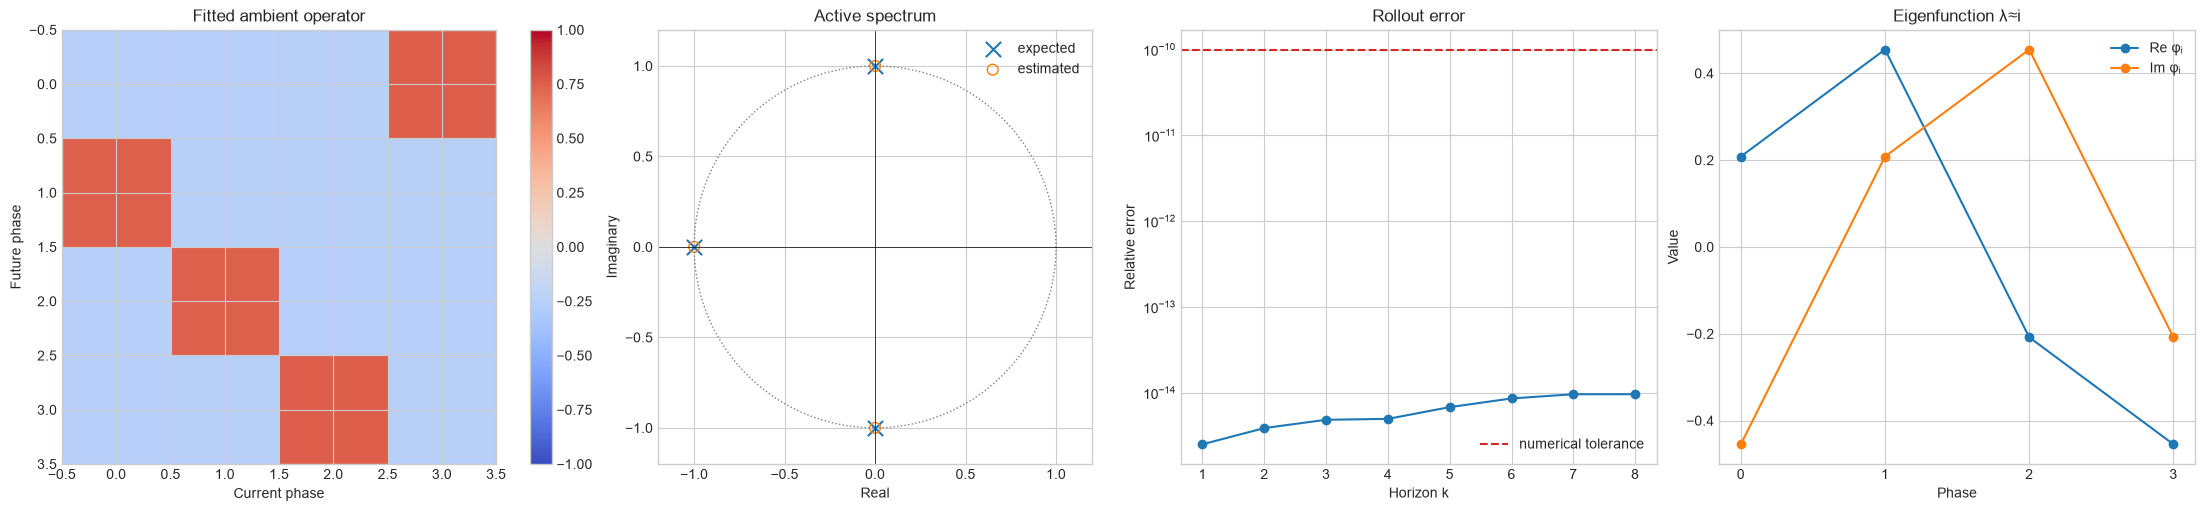

## Result analysis

- Mathematical check: **PASS**.
- The active span has dimension **3**: the constant mode is removed.
- Mean/maximum spectral error: **1.14e-15 / 2.11e-15**.
- Active intertwining error: **1.59e-15**.
- Maximum rollout error through eight steps: **9.62e-15**.
- Maximum left-eigenvector residual: **1.15e-15**.

The ambient least-squares matrix may act arbitrarily along the constant direction unused by the data. The relevant spectrum is its restriction to the active span, where we recover `−1`, `i`, and `−i`. This check prevents an unidentified extra eigenvalue from being mistaken for a learned Koopman mode.


In [4]:
mode_index = int(np.argmin(np.abs(left_eigenvalues - 1.0j)))
ambient_left_mode = left_vectors[mode_index] @ basis.T
phase_features = centered_phase_indicators(np.arange(4), NUM_PHASES)
mode_values = phase_features @ ambient_left_mode
mode_future = centered_phase_indicators((np.arange(4) + 1) % 4, NUM_PHASES) @ ambient_left_mode
mode_residual = mode_future - left_eigenvalues[mode_index] * mode_values
assert np.max(np.abs(mode_residual)) < TOLERANCE

fig, axes = plt.subplots(1, 4, figsize=(22, 5), constrained_layout=True)
image = axes[0].imshow(fitted_operator, cmap="coolwarm", vmin=-1, vmax=1)
axes[0].set(title="Fitted ambient operator", xlabel="Current phase", ylabel="Future phase")
fig.colorbar(image, ax=axes[0], fraction=0.046)
axes[1].scatter(expected_spectrum.real, expected_spectrum.imag, s=120, marker="x", label="expected")
axes[1].scatter(estimated_spectrum.real, estimated_spectrum.imag, s=60, facecolors="none", edgecolors="tab:orange", label="estimated")
circle = plt.Circle((0, 0), 1, fill=False, linestyle=":", color="gray")
axes[1].add_patch(circle)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].axvline(0, color="black", linewidth=0.5)
axes[1].set(title="Active spectrum", xlabel="Real", ylabel="Imaginary", aspect="equal", xlim=(-1.2, 1.2), ylim=(-1.2, 1.2))
axes[1].legend()
axes[2].semilogy(np.arange(1, 9), np.maximum(rollout_errors, 1e-18), marker="o")
axes[2].axhline(TOLERANCE, color="tab:red", linestyle="--", label="numerical tolerance")
axes[2].set(title="Rollout error", xlabel="Horizon k", ylabel="Relative error")
axes[2].legend()
axes[3].plot(np.arange(4), mode_values.real, marker="o", label="Re φᵢ")
axes[3].plot(np.arange(4), mode_values.imag, marker="o", label="Im φᵢ")
axes[3].set(title="Eigenfunction λ≈i", xlabel="Phase", ylabel="Value", xticks=np.arange(4))
axes[3].legend()
plt.show()

display(Markdown(f"""## Result analysis

- Mathematical check: **{'PASS' if passed else 'FAIL'}**.
- The active span has dimension **{metrics['active_rank']}**: the constant mode is removed.
- Mean/maximum spectral error: **{metrics['spectral_mean_absolute_error']:.2e} / {metrics['spectral_max_absolute_error']:.2e}**.
- Active intertwining error: **{metrics['intertwining_error']:.2e}**.
- Maximum rollout error through eight steps: **{metrics['max_eight_step_rollout_error']:.2e}**.
- Maximum left-eigenvector residual: **{metrics['max_left_eigenvector_residual']:.2e}**.

The ambient least-squares matrix may act arbitrarily along the constant direction unused by the data. The relevant spectrum is its restriction to the active span, where we recover `−1`, `i`, and `−i`. This check prevents an unidentified extra eigenvalue from being mistaken for a learned Koopman mode.
"""))